# Data cleaning Desafío 1

## Import libraries

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read files

In [8]:
DATA_RRHH_RAW_FILE = '../Data/raw/raw_data_25052026.csv'

In [9]:
df_RRHH = pd.read_csv(DATA_RRHH_RAW_FILE)
df_RRHH.sample(5)

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
642,11,23,8,2,1,289,36,13,33,"265,615",...,0,1,2,1,0,1,90,172,30,1
367,36,13,8,5,1,118,13,18,50,"265,615",...,0,1,1,1,0,0,98,178,31,3
560,17,23,2,6,2,179,22,17,40,"264,249",...,0,2,2,0,1,0,63,170,22,2
308,14,23,1,3,2,155,12,14,34,"330,061",...,0,1,2,1,0,0,95,196,25,4
668,36,23,4,2,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,1


# Data cleaning

In [10]:
df_RRHH.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,740.0,18.017568,11.021247,1.0,9.0,18.0,28.0,36.0
Reason_absence,740.0,19.216216,8.433406,0.0,13.0,23.0,26.0,28.0
Month_absence,740.0,6.324324,3.436287,0.0,3.0,6.0,9.0,12.0
Day_week,740.0,3.914865,1.421675,2.0,3.0,4.0,5.0,6.0
Seasons,740.0,2.544595,1.111831,1.0,2.0,3.0,4.0,4.0
Transportation_expense,740.0,221.329730,66.952223,118.0,179.0,225.0,260.0,388.0
Distance_Residence_Work,740.0,29.631081,14.836788,5.0,16.0,26.0,50.0,52.0
Service_time,740.0,12.554054,4.384873,1.0,9.0,13.0,16.0,29.0
Age,740.0,36.450000,6.478772,27.0,31.0,37.0,40.0,58.0
Hit_target,740.0,94.587838,3.779313,81.0,93.0,95.0,97.0,100.0


In [13]:
df_RRHH.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   ID                       740 non-null    int64
 1   Reason_absence           740 non-null    int64
 2   Month_absence            740 non-null    int64
 3   Day_week                 740 non-null    int64
 4   Seasons                  740 non-null    int64
 5   Transportation_expense   740 non-null    int64
 6   Distance_Residence_Work  740 non-null    int64
 7   Service_time             740 non-null    int64
 8   Age                      740 non-null    int64
 9   Work_load_Average_day    740 non-null    str  
 10  Hit_target               740 non-null    int64
 11  Disciplinary_failure     740 non-null    int64
 12  Education                740 non-null    int64
 13  Son                      740 non-null    int64
 14  Social_drinker           740 non-null    int64
 15  Social_smoker    

trim?

## Change Work_load_Average_day to float (, to .)

In [23]:
df_RRHH['Work_load_Average_day'] = df_RRHH['Work_load_Average_day'].str.replace(',', '.', regex=False).astype(float)

In [24]:
df_RRHH.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       740 non-null    int64  
 1   Reason_absence           740 non-null    int64  
 2   Month_absence            740 non-null    int64  
 3   Day_week                 740 non-null    int64  
 4   Seasons                  740 non-null    int64  
 5   Transportation_expense   740 non-null    int64  
 6   Distance_Residence_Work  740 non-null    int64  
 7   Service_time             740 non-null    int64  
 8   Age                      740 non-null    int64  
 9   Work_load_Average_day    740 non-null    float64
 10  Hit_target               740 non-null    int64  
 11  Disciplinary_failure     740 non-null    int64  
 12  Education                740 non-null    int64  
 13  Son                      740 non-null    int64  
 14  Social_drinker           740 non-null

# Month_absence 0 - eliminar?

In [25]:
df_RRHH[df_RRHH['Month_absence'] == 0]

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
737,4,0,0,3,1,118,14,13,40,271.219,...,0,1,1,1,0,8,98,170,34,0
738,8,0,0,4,2,231,35,14,39,271.219,...,0,1,2,1,0,2,100,170,35,0
739,35,0,0,6,3,179,45,14,53,271.219,...,0,1,1,0,0,1,77,175,25,0


# Age - education - Son ok

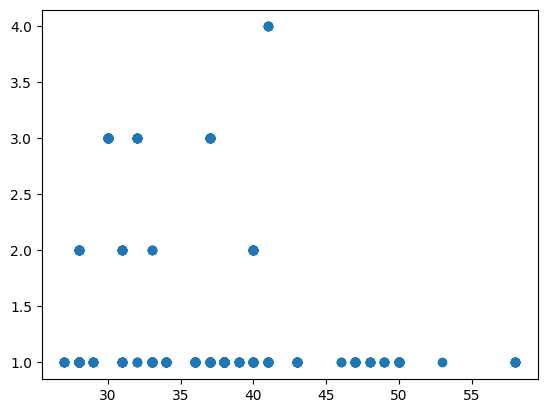

In [29]:
plt.scatter(df_RRHH['Age'],df_RRHH['Education'])

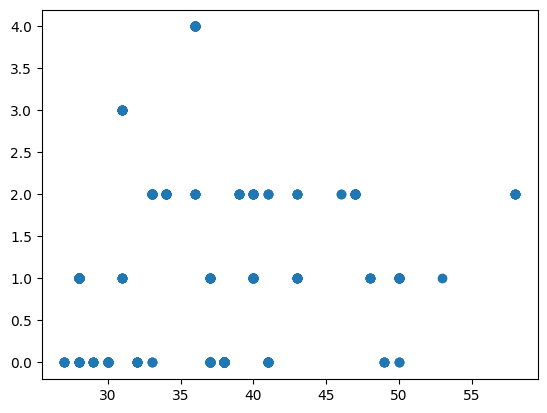

In [30]:
plt.scatter(df_RRHH['Age'],df_RRHH['Son'])

# BMI

In [31]:
df_RRHH['BMI_calculated'] = (
    df_RRHH['Weight'] / ((df_RRHH['Height'] / 100) ** 2)
).astype(int)

In [32]:
df_RRHH[df_RRHH['BMI_calculated'] != df_RRHH['Body_mass_index']]

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours,BMI_calculated
0,14,11,11,2,4,155,12,14,34,284.031,...,1,2,1,0,0,95,196,25,120,24
1,36,13,4,4,3,118,13,18,50,239.409,...,1,1,1,0,0,98,178,31,120,30
2,9,6,7,3,1,228,14,16,58,264.604,...,1,2,0,0,1,65,172,22,120,21
4,9,12,3,3,2,228,14,16,58,222.196,...,1,2,0,0,1,65,172,22,112,21
6,36,13,6,4,3,118,13,18,50,377.550,...,1,1,1,0,0,98,178,31,80,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,15,0,11,3,4,291,31,12,40,268.519,...,1,1,1,0,1,73,171,25,0,24
733,36,0,5,3,3,118,13,18,50,237.656,...,1,1,1,0,0,98,178,31,0,30
736,21,0,6,2,3,268,11,8,33,275.089,...,2,0,0,0,0,79,178,25,0,24
737,4,0,0,3,1,118,14,13,40,271.219,...,1,1,1,0,8,98,170,34,0,33


In [34]:
df_RRHH['BMI_calculated_up'] = np.ceil(
    df_RRHH['Weight'] / ((df_RRHH['Height'] / 100) ** 2)
).astype(int)

In [35]:
df_RRHH[df_RRHH['BMI_calculated_up'] != df_RRHH['Body_mass_index']]

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours,BMI_calculated,BMI_calculated_up
3,28,9,7,3,1,225,26,9,28,230.290,...,1,0,0,2,69,169,24,112,24,25
5,11,19,3,2,3,289,36,13,33,222.196,...,2,1,0,1,90,172,30,104,30,31
9,34,19,12,3,4,118,10,10,37,261.306,...,0,0,0,0,83,172,28,64,28,29
10,22,1,10,4,4,179,26,9,30,265.017,...,0,0,0,0,56,171,19,64,19,20
11,26,19,5,6,3,300,26,13,43,237.656,...,2,1,1,1,77,175,25,64,25,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,11,0,11,4,4,289,36,13,33,268.519,...,2,1,0,1,90,172,30,0,30,31
732,5,0,11,5,4,235,20,13,43,268.519,...,1,1,0,0,106,167,38,0,38,39
734,23,0,5,4,3,378,49,11,36,237.656,...,2,0,1,4,65,174,21,0,21,22
735,2,0,6,2,3,235,29,12,48,275.089,...,1,0,1,5,88,163,33,0,33,34
